In [1]:
import sys
sys.path.append("..")

import jax, os, corner
import jax.numpy as jnp
from jax import grad, config
import matplotlib.pyplot as plt
import numpy as np
config.update("jax_enable_x64", True)
config.update("jax_debug_nans", True)
from functools import partial
from models.priors import Mc_eta_uniform_masses_draw

from models.gw150914_v2 import gwfast_LVGW150914
from models.gwfast.waveforms import TaylorF2_RestrictedPN, IMRPhenomD

from src.pampel import ula_sampler_full_jax_jit

from src.pampel_stepstone import ula_sampler_full_jax_jit as ula_sampler_full_jax_jit_stepstone

from src.helper import rejection_sampling

from src.helper import plot_cross_section, animate_particles

print(jax.devices())

[cuda(id=0)]


In [2]:
# Initialize model
# model = gwfast_LVGW150914(wf_model=IMRPhenomD, nbins=100)
model = gwfast_LVGW150914(wf_model=IMRPhenomD, nbins=100) # NOTE: I've changed priors on tc to 100 ms delta
# model = gwfast_LVGW150914(wf_model=IMRPhenomD)

Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_L_ASD_GW150914.txt 
Using ASD from file /home/al44828/projects/sSVN_GW/notebooks/LIGO_H_ASD_GW150914.txt 
fmin:  20.0
fmax:  512.0
df_standard:  4.92
nbins:  100
SNR at true values: 25.93


In [3]:
# Confirmation that the potential and the gradient are in agreement!
x = model._newDrawFromPrior(1)
test1 = jax.jacobian(model.potential)(x)
test2 = model.gradient_potential(x)
print(test1)
print(test2)

157671 samples obtained from rejection sampling
[[[-6.30329521e+00  2.78347094e+00 -1.23527129e+01  2.66084324e-02
    6.93294746e+00  3.59847500e+01 -1.28690132e+01  1.26608043e+00
   -8.76497781e+00  4.56043443e+01  2.41618467e+01]]]
[[-6.30329521e+00  2.78347094e+00 -1.23527129e+01  2.66084324e-02
   6.93294746e+00  3.59847500e+01 -1.28690132e+01  1.26608043e+00
  -8.76497781e+00  4.56043443e+01  2.41618467e+01]]


In [ ]:
grad, fisher = model.gradient_potential_GAUSS(model.true_params[None, ...])
covariance = jnp.linalg.inv(fisher[0])
damped_covariance = jnp.linalg.inv(fisher[0] + jnp.diag(1 / (model.upper_bound - model.lower_bound) ** 2))
tikhinov_covariance = jnp.linalg.inv(fisher[0] + 0.01 * jnp.eye(11))
print('Original variances: \n', covariance[np.arange(11), np.arange(11)])
print('Damped variances: \n', damped_covariance[np.arange(11), np.arange(11)])
print('Tikhinov variances: \n', tikhinov_covariance[np.arange(11), np.arange(11)])

In [ ]:
damped_fisher = fisher[0] + 0.01 * jnp.eye(11)

In [ ]:
new_fisher = damped_fisher / jnp.mean(jnp.linalg.eigvalsh(damped_fisher))

In [ ]:
print(jnp.linalg.eigvalsh(damped_fisher))
print(jnp.linalg.eigvalsh(new_fisher))

In [ ]:
new_fisher = fisher / (jnp.trace(fisher.squeeze()) / model.DoF)

In [ ]:
eigvals, eigvecs = jnp.linalg.eigh(fisher.squeeze())

In [ ]:
# subset_params = jnp.array([6, 8])
fisher_subset = fisher[:, subset_params[:, None], subset_params]

In [ ]:
eigvals, eigvecs = jnp.linalg.eigh(fisher_subset)

In [ ]:
eigvecs[0]

In [ ]:
(1 / ((model.upper_bound - model.lower_bound) ** 2))

In [ ]:
jnp.dot(eigvecs[0, 0], eigvecs[0, 1])

In [ ]:
damp = jnp.eye(model.DoF) * 0.001
damp = damp.at[0,0].set()
jnp.linalg.eigvalsh(fisher + jnp.diag())

In [ ]:
eigvecs[0]

In [ ]:
jnp.linalg.eigvalsh(fisher)
# jnp.linalg.eigvalsh(new_fisher)

# Full parameter space test

In [25]:
# Setup and run sampler
n_iter = 40000
n_particles = 200

# Use scalar stepsize
# eps = 2e-2
# eps = 1e-1 # Works well with average Gauss Newton
# eps = 2e-1 # Tests with Fisher
# eps = 1 # Tests with Fisher
# eps = 0.5 # Tests with Fisher
# eps = 1.3
# eps = 1.2
# eps = 1
eps = 0.8


# eps = jnp.ones(model.DoF)
# eps = eps.at[model.bounded_coordinates].set(1e-6)
# eps = eps.at[model.periodic_coordinates].set(1e-6)

# Birth death
# stride = n_iter + 1
# stride = 100
stride = 100
# rate = eps * 0.01
# rate = eps * 0.01 # USE THIS !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
rate = eps * 0.1
# rate = eps * 0.01
sigmas = jnp.ones(11) * 0.1
# sigmas = jnp.ones(11) 

# Initial draw from prior
X0 = model._newDrawFromPrior(n_particles)

# X0 = X0.at[:,2:].set(model.true_params[2:])

key = jax.random.PRNGKey(0)

#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# NOTE: WE'RE USING DEBUGGING SCAN RIGHT NOW!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# print('using debugging scan')
#!!!!!!!!!!!!!!!!!!!!!!!!
sam = ula_sampler_full_jax_jit_stepstone(key, model.potential, model.gradient_potential, n_iter, eps, X0, model.lower_bound, model.upper_bound, stride, rate, sigmas, model.bounded_coordinates, model.periodic_coordinates)
# sam = ula_sampler_full_jax_jit_stepstone(key, jax.jit(model.potential), jax.jit(model.gradient_potential_GAUSS), n_iter, eps, X0, model.lower_bound, model.upper_bound, stride, rate, sigmas, model.bounded_coordinates, model.periodic_coordinates)
# sam = ula_sampler_full_jax_jit(key, model.potential, model.gradient_potential, n_iter, eps, X0, model.lower_bound, model.upper_bound, stride, rate, sigmas, model.bounded_coordinates, model.periodic_coordinates)

157910 samples obtained from rejection sampling


In [5]:
bilby_samples = np.load('bilby_samples.npy')
bilby_samples[:,7] *= 1000
# corner.corner(bilby_samples)

In [ ]:

corner.corner(bilby_samples)

In [ ]:
bilby_samples.shape

In [23]:
sam = ula_sampler_full_jax_jit_stepstone(key, model.potential, model.gradient_potential, n_iter, eps, sam[-1], model.lower_bound, model.upper_bound, stride, rate, sigmas, model.bounded_coordinates, model.periodic_coordinates)


In [ ]:
cwd = os.getcwd()

path = os.path.join(cwd, 'long_run_checkpoints')

# save_path = os.path.join(path, 'checkpoint_5.npy')
# save_path = os.path.join(path, 'checkpoint_2_9.npy')
save_path = os.path.join(path, 'checkpoint_qn_4.npy')

sam = np.load(save_path)

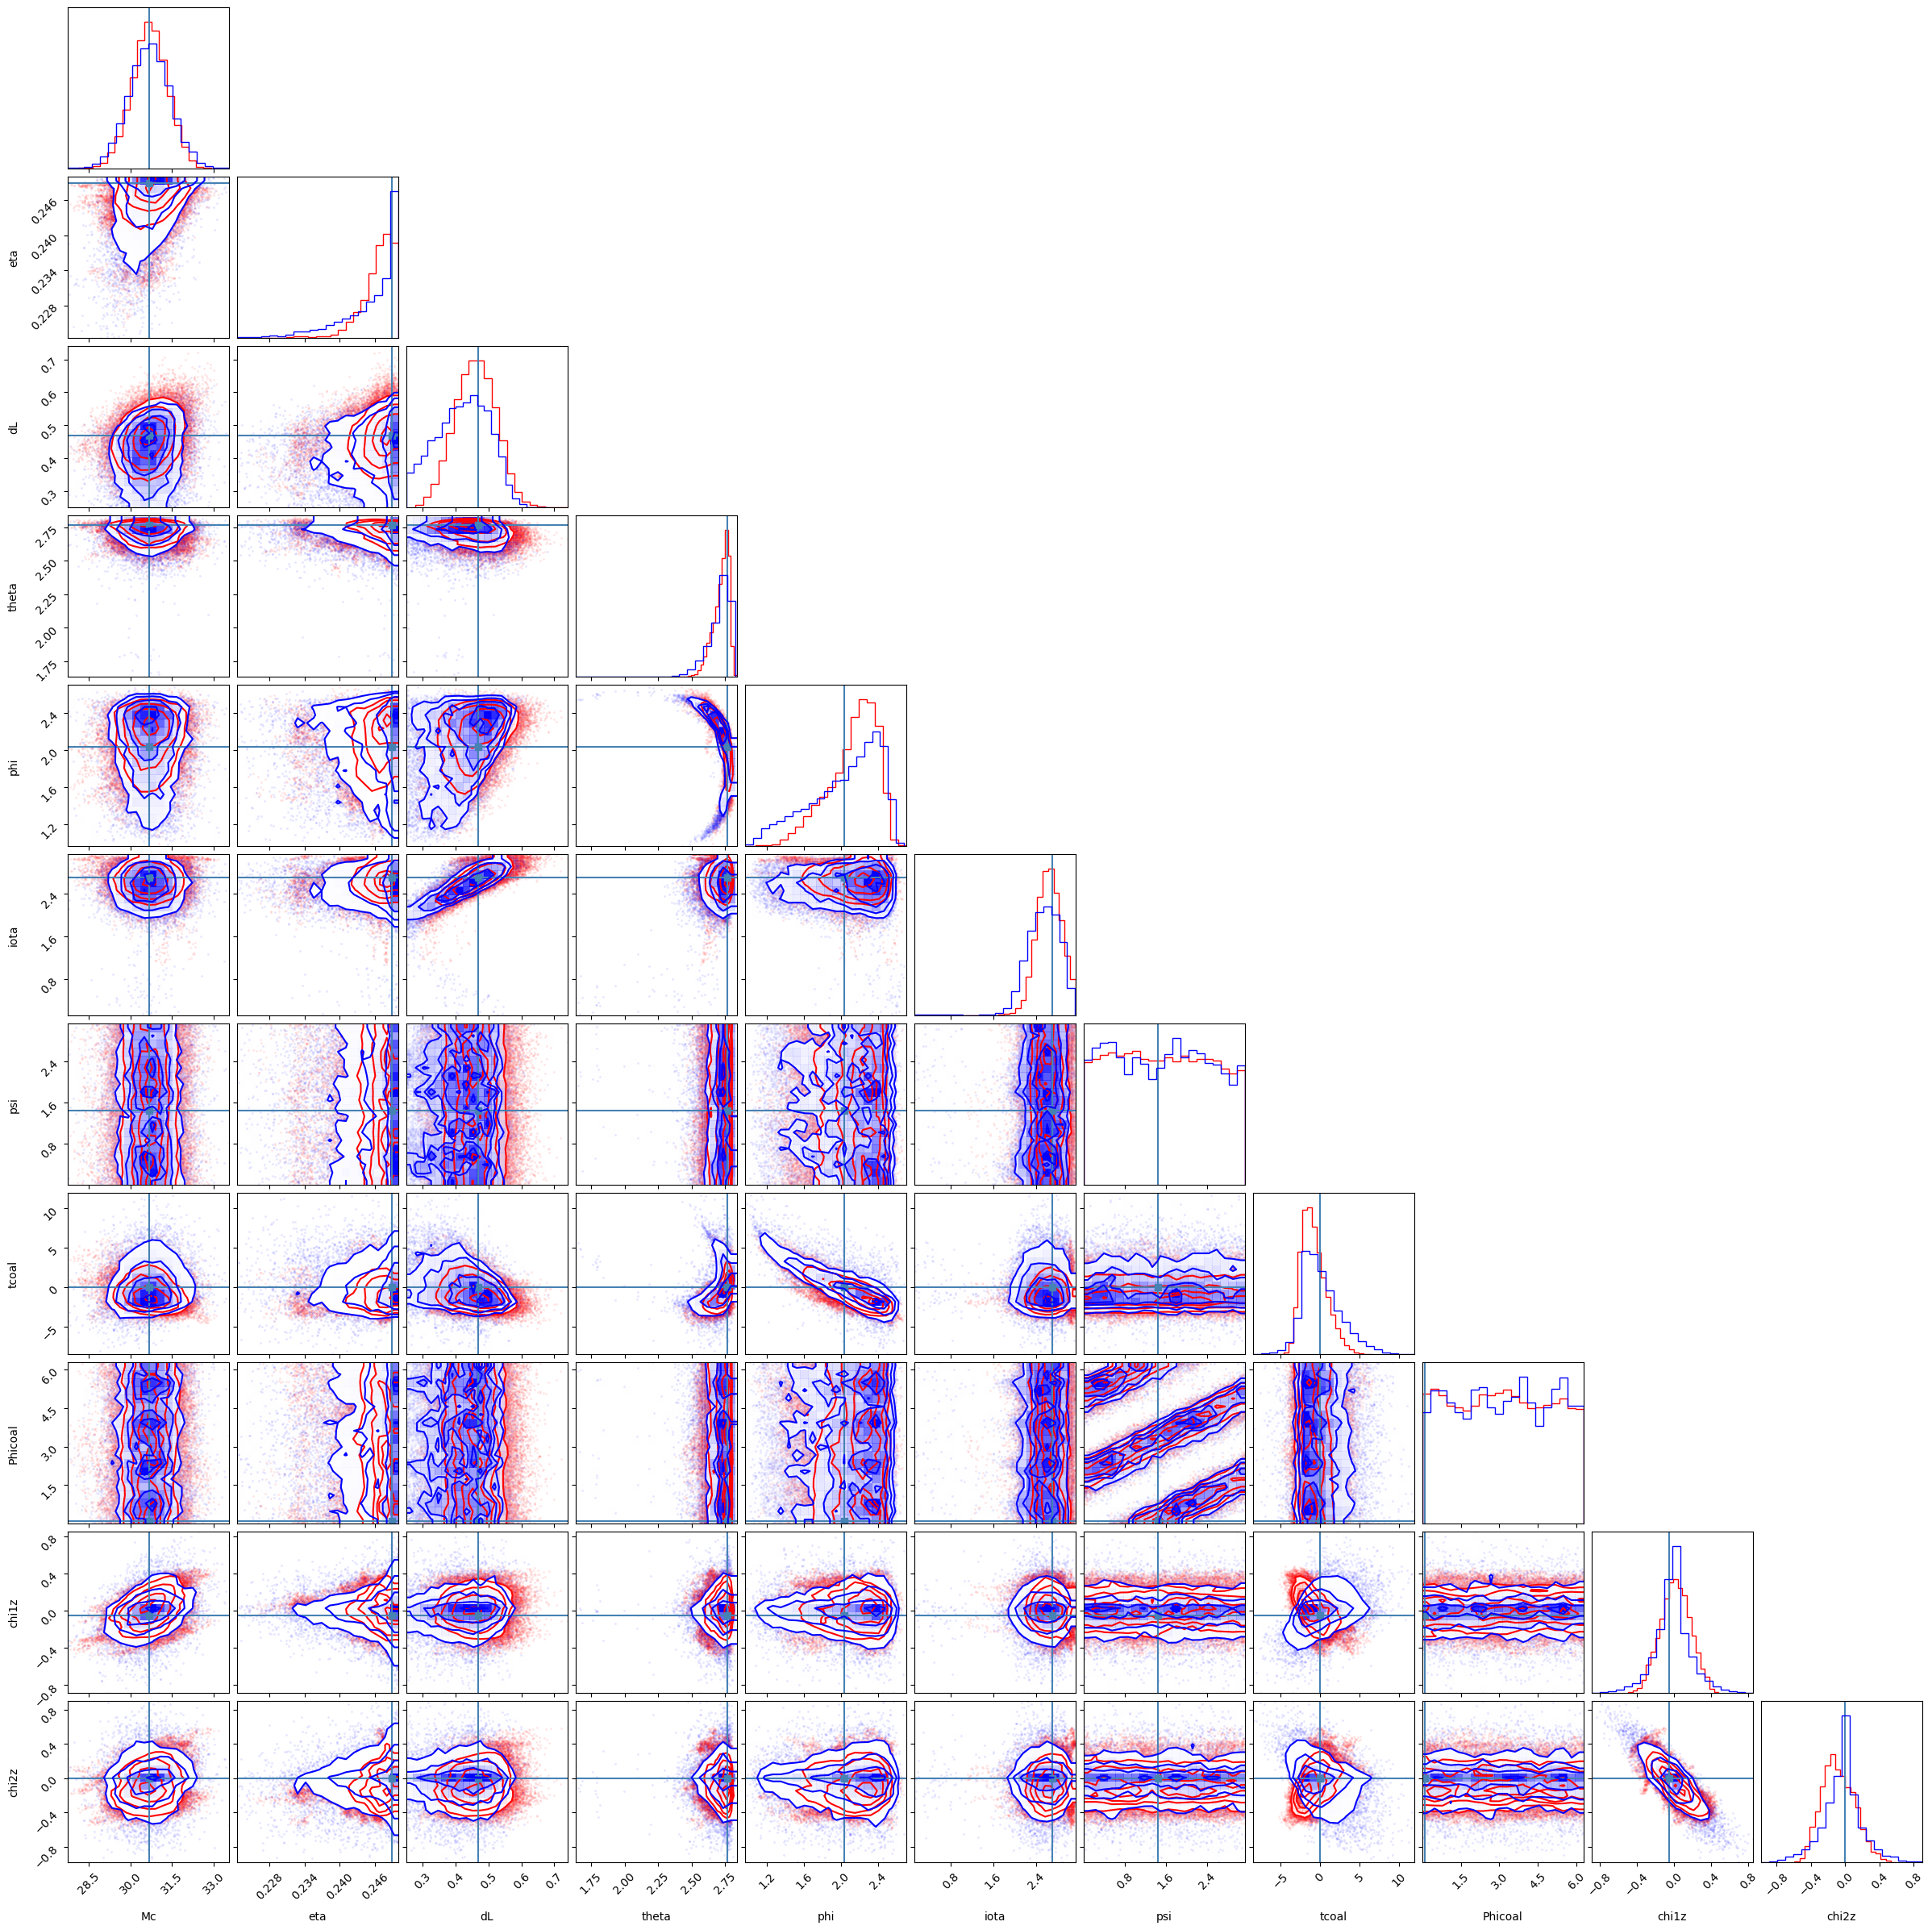

In [26]:
# Cornerplot results
reshaped_matrix = np.array(sam.reshape((sam.shape[0] * sam.shape[1], 11)))

reshaped_matrix[:, 7] -= model.true_params[7]
reshaped_matrix[:, 1] /= 100

# fig = corner.corner(np.array(model._newDrawFromPrior(50000)), color='r', hist_kwargs={'density':True})
# corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=model.gwfast_param_order, truths=model.true_params, fig=fig)

true = model.true_params.at[1].divide(100)
true = true.at[7].add(-model.true_params[7])

fig = corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=model.gwfast_param_order, truths=true, color='r')

corner.corner(bilby_samples, fig=fig, color='b', hist_kwargs={'density':True})

fig.savefig('wrks.svg')

In [ ]:
np.save('langevin_bd_samples2.npy', reshaped_matrix[-50000:])

In [ ]:
np.load('langevin_bd_samples2.npy')

In [ ]:
import h5py

with h5py.File('ZeroNoise1_IMRPD_GW150914_results.hdf5', 'r') as f:
    # List all groups
    # bilby_samples = f['samples'][:]   
    # bilby_inj_params = f['injection_parameters'].keys()
    # bilby_param_labels = f['parameter_labels'][:]

    # print(bilby_inj_params)
    # print(bilby_param_labels)
    print(f['sampler'])
    # print("Keys: %s" % f.keys())

In [ ]:
bilby_inj_params

In [ ]:
print(bilby_param_labels)

In [ ]:
labels_test = [b'$\\mathcal{M}$', b'$q$', b'$\chi_1$', b'$\\chi_2$', b'$d_L$', b'$\\cos\\theta_{JN}$', b'$\\psi$', b'delta_phase', b'$\\epsilon$', b'$\\kappa$', b'$t_c$']

In [ ]:
labels_test = ['M', 'q', 'chi_1', 'chi_2', 'd_L', 'cos(theta_{JN})', 'psi', 'delta_phase', 'eps', 'kappa', 't_c']

In [ ]:
corner.corner(a, labels=labels_test)

In [ ]:
# Animate 2d marginal flows over 2d cross sections
neg_potential = jax.jit(lambda X: -1 * model.potential(X))
for i in [0]:
    for j in range(11):
        if i < j:
            subset_params = jnp.array([i,j])
            fig, ax = plot_cross_section(subset_params[0], subset_params[1], neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)
            animate_particles(sam[..., subset_params], 50, fig, ax, save_path='margin_flows/%i_%i.gif' % (i,j))

In [ ]:
# Plot cross sections
from src.helper import plot_cross_section
posterior     = jax.jit(lambda X: jnp.exp(-1 * model.potential(X)))
neg_potential = jax.jit(lambda X: -1 * model.potential(X))

# def detfunc(X):
#     grad, gamma = model.gradient_potential_GAUSS(X)
#     damp = 0.0001
#     gamma += damp * jnp.eye(11)[None,...]
#     return jnp.linalg.det(gamma)

# def detfunc(X):
#     grad, gamma = model.gradient_potential_GAUSS(X)
#     return grad


for i in range(model.DoF):
    for j in range(i+1, model.DoF):
        print('Getting cross section for %i, %i' % (i,j))
        # plot_cross_section(i, j, neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)
        # plot_cross_section(i, j, posterior, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)
        plot_cross_section(i, j, jax.jit(detfunc), 500, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)

# Subset experiments

In [ ]:
def coordinate_idx_wrapper(bounded_idxs, periodic_idxs, subset_idxs):
    """
    Organize bounded and periodic coordinates given subset indicies
    NOTE: Assumes increasing index label order
    """
    bounded_coordinates_ = []
    periodic_coordinates_ = []
    j = 0
    for i in subset_idxs:
        if i in bounded_idxs:
            bounded_coordinates_.append(j)
        elif i in periodic_idxs:
            periodic_coordinates_.append(j)
        j += 1
    bounded_coordinates_ = jnp.array(bounded_coordinates_)
    periodic_coordinates_ = jnp.array(periodic_coordinates_)
    return bounded_coordinates_, periodic_coordinates_

def get_subidx_labels(subset_idxs, labels):
    """ 
    Helper method to get labels for cornerplot
    """
    sub_idx_labels = []
    for i in subset_idxs:
        sub_idx_labels.append(labels[i])
    return np.array(sub_idx_labels)

In [ ]:
n_particles = 200

# subset_params = jnp.array([0, 1]) # Specific example.
# subset_params = jnp.array([2, 3]) # Specific example.
# subset_params = jnp.array([3, 4]) # Specific example.
# subset_params = jnp.array([4, 6]) # Specific example.
subset_params = jnp.array([6, 8]) # Specific example. # Nasty
# subset_params = jnp.array([0, 6]) # Specific example. # Nasty
# subset_params = jnp.array([0, 1, 2, 3, 4, 6, 8, 10])

bounded_coordinates_, periodic_coordinates_ = coordinate_idx_wrapper(model.bounded_coordinates, model.periodic_coordinates, subset_params)

X_injection = jnp.tile(model.true_params, n_particles).reshape(n_particles, model.DoF)

def potential_subset(X_red):
    X_ = X_injection.at[:, subset_params].set(X_red)
    return model.potential(X_)

# jaxed_grad = jax.jit(model.gradient_potential)

# def gradient_subset(X_red):
#     X_ = X_injection.at[:, subset_params].set(X_red)
#     return model.gradient_potential(X_)[:, subset_params]

def gradient_subset(X_red):
    X_ = X_injection.at[:, subset_params].set(X_red)
    grad, hess = model.gradient_potential_GAUSS(X_)
    return grad[:, subset_params], hess[:, subset_params[:, None], subset_params]


# Subset definitions needed for run 
n_iter = 5000

eps = 1e-2

# Birth death
stride = n_iter + 1
rate = eps * 100
key = jax.random.PRNGKey(42)
X0 = model._newDrawFromPrior(n_particles)

sigmas = jnp.ones(len(subset_params)) * 0.01

# NOTE: WE'RE DOING STEPSTONE RIGHT NOW!!!
sam = ula_sampler_full_jax_jit_stepstone(key, 
                               potential_subset, 
                               gradient_subset, 
                               n_iter, 
                               eps, 
                               X0[:, subset_params], 
                               model.lower_bound[subset_params], 
                               model.upper_bound[subset_params], 
                               stride, 
                               rate, 
                               sigmas, 
                               bounded_coordinates_, 
                               periodic_coordinates_)

# Interface with this if we want to plot subflows
injection_ensemble = np.tile(model.true_params, n_particles).reshape(n_particles, model.DoF)
samples = np.tile(injection_ensemble, n_iter).reshape(n_iter, n_particles, model.DoF)
samples[:,:,subset_params] = sam

In [ ]:
# If we want to interface in a normal way
reshaped_matrix = np.array(sam.reshape((sam.shape[0] * sam.shape[1], len(subset_params))))
corner.corner(reshaped_matrix[-50000:], hist_kwargs={'density':True}, labels=get_subidx_labels(subset_params, model.gwfast_param_order), truths=model.true_params[subset_params])

In [ ]:
neg_potential = jax.jit(lambda X: -1 * model.potential(X))

fig, ax = plot_cross_section(subset_params[0], subset_params[1], neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)
i = subset_params[0]
j = subset_params[1]
animate_particles(samples[..., subset_params], 50, fig, ax, save_path='animation_%i_%i_langevin.gif' % (i,j))

In [ ]:
# neg_potential = jax.jit(lambda X: -1 * model.potential(X))
for i in [0]:
    for j in range(10):
        if i < j :
            subset_params_ = jnp.array([i,j])
            fig, ax = plt.subplots()
            animate_particles(sam[..., subset_params_], 100, fig, ax, save_path='margin_flows/%i_%i.gif' % (i,j))

In [ ]:
print(model.lower_bound[subset_params])
print(model.upper_bound[subset_params])
print(bounded_coordinates_)
print(periodic_coordinates_)
print(X_injection[0:3, :])

In [ ]:
neg_potential = lambda x: -1 * jax.jit(model.potential)(x)

In [ ]:
fig, ax = plot_cross_section(subset_params[0], subset_params[1], neg_potential, 200, model.true_params, model.lower_bound, model.upper_bound, model.gwfast_param_order)

In [ ]:
animate_particles(sam, 100, fig, ax, save_path='animation_flow2.gif')

In [ ]:
# Check variances

from src.reparameterization import reparameterized_gradient

X = model._newDrawFromPrior(1000)
gmlpt_X = model.gradient_potential(X)

Y, gmlpt_Y = reparameterized_gradient(X, gmlpt_X, model.lower_bound, model.upper_bound)

vals = gmlpt_Y.at[:, model.periodic_coordinates].set(gmlpt_X[:, model.periodic_coordinates]) 

variances = np.var(np.abs(vals), axis=0)

# Plot the gradient variance
for i in np.argsort(variances)[::-1]:
        plt.hist(vals[:,i], bins=50, label=model.gwfast_param_order[i])
        print(np.max(np.abs(vals[:,i])), i)
plt.title('Gradient variance')
plt.legend()


plt.bar(model.gwfast_param_order, np.median(np.abs(vals), axis=0))

In [ ]:





    #######################################################



    # THIS ONE WORKS ######################################
    # particle_grid = np.zeros((N, d))
    # for i in range(d): # Fix all other parameters
    #     if i == index1:
    #         particle_grid[:, i] = X.flatten()
    #     elif i == index2:
    #         particle_grid[:, i] = Y.flatten()
    #     else:
    #         particle_grid[:, i] = np.ones(N) * injection[i]
    #######################################################